<div align="center" style="color:CornSilk; background-color:#2e2e2e; padding:20px; border-radius:10px;">

# Introducción al momentum clásico y de Nesterov

### Redes neuronales y aprendizaje profundo
### Tema 4: Aspectos prácticos en el entrenamiento de redes neuronales

**Master Universitario en Inteligencia Artificial**

**Universidad Internacional de la Rioja (UNIR)**  



---

</div>

### Dataset

Comencemos cargando el dataset iris, que ya conocemos.

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Cargar el dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

### Vamos a echar un vistazo al dataset

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

#### Distribución de las características
Vamos a visualizar la distribución de las características del dataset usando histogramas y gráficos de caja para identificar posibles patrones y outliers.

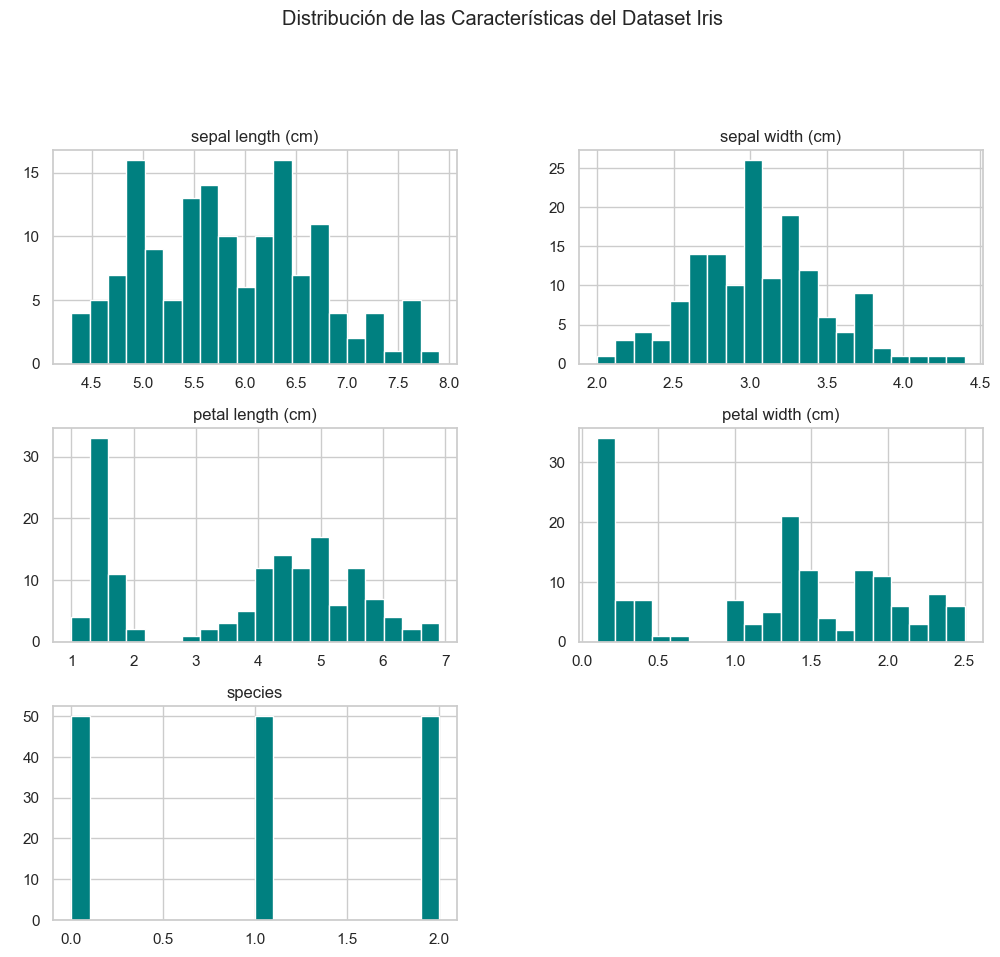

In [4]:
# Histogramas de las características
sns.set(style="whitegrid")
df.hist(bins=20, figsize=(12, 10), color='teal')
plt.suptitle('Distribución de las Características del Dataset Iris', y=1.02)
plt.show()

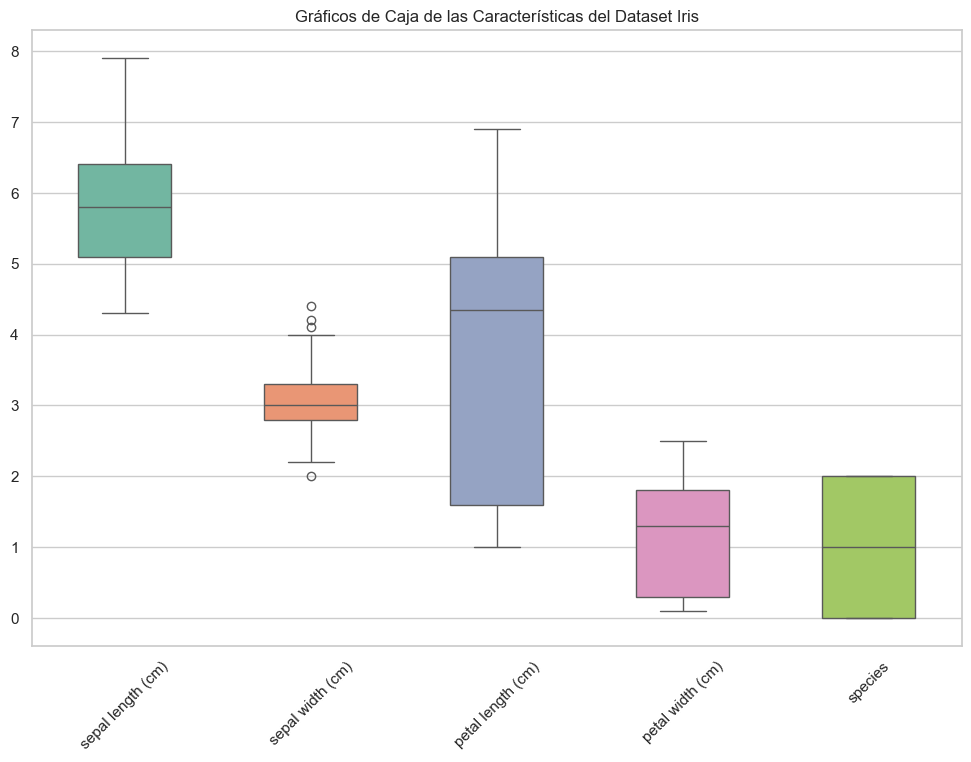

In [5]:
# Gráficos de caja para identificar outliers
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, width=0.5, palette='Set2')
plt.title('Gráficos de Caja de las Características del Dataset Iris')
plt.xticks(rotation=45)
plt.show()

Cantidad de datos por clase

        Clase  Cantidad de Muestras
0      setosa                    50
1  versicolor                    50
2   virginica                    50


C:\Users\juano\AppData\Local\Temp\ipykernel_53192\3461717758.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_labels, y=class_counts.values, palette='viridis')


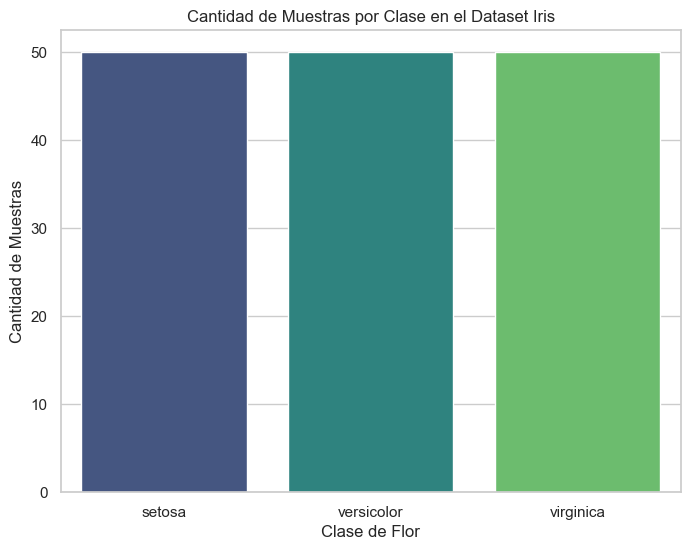

In [6]:
# Mostrar la cantidad de datos por clase
class_counts = df['species'].value_counts()
class_labels = [iris.target_names[i] for i in class_counts.index]

# Mostrar la tabla de conteos
print(pd.DataFrame({'Clase': class_labels, 'Cantidad de Muestras': class_counts.values}))

# Visualizar la cantidad de muestras por clase
plt.figure(figsize=(8, 6))
sns.barplot(x=class_labels, y=class_counts.values, palette='viridis')
plt.title('Cantidad de Muestras por Clase en el Dataset Iris')
plt.ylabel('Cantidad de Muestras')
plt.xlabel('Clase de Flor')
plt.show()

### Creamos el dataset de entrenamiento

In [7]:
# Escalar las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Convertir a tensores de PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

### Definición del modelo

In [8]:
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

model = SimpleNN(input_size=4, hidden_size=10, num_classes=3)

In [9]:
print(model)

SimpleNN(
  (fc1): Linear(in_features=4, out_features=10, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=10, out_features=3, bias=True)
)


### Función de pérdida

Usaremos cross-entropy para clasificación multicategoría.

In [10]:
criterion = nn.CrossEntropyLoss()

### Función de entrenamiento

In [11]:
def train_model(model, criterion, optimizer, train_loader, epochs):
    model.train()
    loss_history = []
    for epoch in range(epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            # Reiniciar gradientes
            optimizer.zero_grad()
            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            # Backward pass y optimización
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        # Calcular pérdida promedio
        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)
    return loss_history

# Introducción al Momentum de Nesterov
 
El **Momentum de Nesterov** es una técnica de optimización que mejora la convergencia durante el entrenamiento de modelos de aprendizaje profundo. Es una variante del método de momentum estándar que proporciona una mejor anticipación de la dirección de descenso, lo que puede resultar en una convergencia más rápida y estable.
 
### Fundamentos Teóricos

#### Momentum Estándar:
El método de momentum clásico actualiza los parámetros de la siguiente manera:

$$
v_t = \gamma v_{t-1} + \eta \nabla J(\theta_{t-1})
$$

$$
\theta_t = \theta_{t-1} - v_t
$$

Donde:
- $v_t$ es la velocidad o el término de momentum.
- $\gamma$ es el coeficiente de momentum (0 < $\gamma$ < 1).
- $\eta$ es la tasa de aprendizaje.
- $\nabla J(\theta_{t-1})$ es el gradiente de la función de pérdida respecto a los parámetros $\theta$ (a veces llamo a la función de pérdida $L$).
 
#### Momentum de Nesterov:
El Momentum de Nesterov modifica el método estándar evaluando el gradiente no en la posición actual, sino en una posición adelantada:

$$
v_t = \gamma v_{t-1} + \eta \nabla J(\theta_{t-1} - \gamma v_{t-1})
$$
 
$$
\theta_t = \theta_{t-1} - v_t
$$
 
La diferencia clave es que el gradiente se calcula en $\theta_{t-1} - \gamma v_{t-1}$, anticipando hacia dónde se moverán los parámetros, lo que puede proporcionar una corrección más precisa.

La idea es que al anticipar el próximo paso, podemos ajustar el movimiento actual para corregir cualquier desviación, permitiendo una convergencia más eficiente especialmente en regiones con superficies de error complicadas.


### Entrenamos el modelo con y sin momento de nesterov

In [ ]:
# Preparar el DataLoader
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=16, shuffle=True)

# Entrenar el modelo con SGD sin Momentum
model_sgd = SimpleNN(4, 10, 3)
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01)
loss_history_sgd = train_model(model_sgd, criterion, optimizer_sgd, train_loader, epochs=100)

# Entrenar con momento clásico
model_momentum = SimpleNN(4, 10, 3)
optimizer_momentum = torch.optim.SGD(model_momentum.parameters(), lr=0.01, momentum=0.9)
loss_history_momentum = train_model(model_momentum, criterion, optimizer_momentum, train_loader, epochs=100)

# Entrenar el modelo con Momentum de Nesterov
model_nesterov = SimpleNN(4, 10, 3)
optimizer_nesterov = torch.optim.SGD(model_nesterov.parameters(), lr=0.01, momentum=0.9, nesterov=True)
loss_history_nesterov = train_model(model_nesterov, criterion, optimizer_nesterov, train_loader, epochs=100)

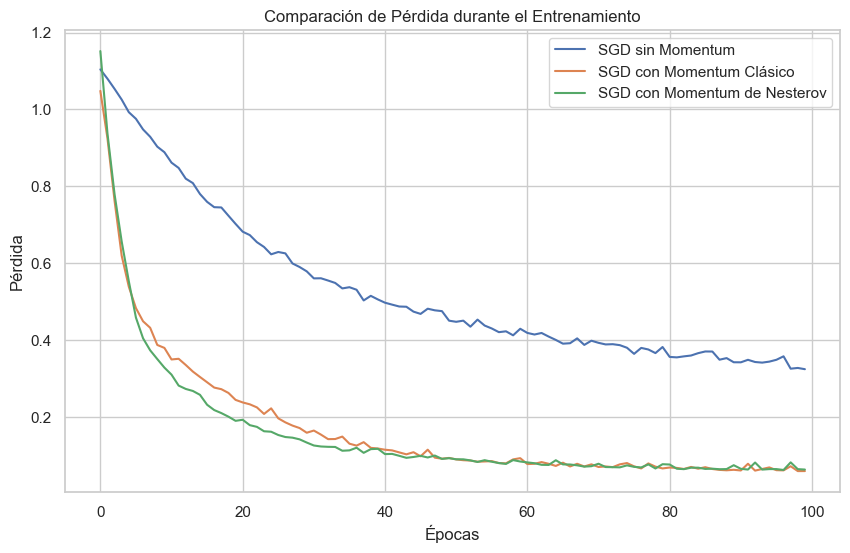

In [13]:
# Graficar las curvas de pérdida
plt.figure(figsize=(10, 6))
plt.plot(loss_history_sgd, label='SGD sin Momentum')
plt.plot(loss_history_momentum, label='SGD con Momentum Clásico')
plt.plot(loss_history_nesterov, label='SGD con Momentum de Nesterov')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Comparación de Pérdida durante el Entrenamiento')
plt.legend()
plt.show()

### Conclusiones

Se puede apreciar cómo el momentum mejora la convergencia y, en este ejemplo, el momentum de Nesterov funciona mejor que el clásico.